In [2]:
from RRAM import Plot_PostProcess as pplt
from RRAM import Constants as cte
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.optimize import curve_fit

num_simulation = 13

In [47]:
carpeta_results = 'Results'

ruta_raiz = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/'

simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation + 1}/')
figures_path = os.path.join(carpeta_results, 'Figures')


set_simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation + 1}/set/')
os.makedirs(set_simulation_path, exist_ok=True)

reset_simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation + 1}/reset/')
os.makedirs(reset_simulation_path, exist_ok=True)

# region Configuracion del plot


def config_ax(ax):
    ax.grid(which='major', color='#DDDDDD', linewidth=0.8, zorder=-1)
    # Show the minor grid as well. Style it in very light gray as a thin,
    # dotted line.
    ax.grid(which='minor', color='#DEDEDE', linestyle=':', linewidth=0.5, zorder=-1)
    # Make the minor ticks and gridlines show.
    ax.minorticks_on()

    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)


def setup_plt(plt, latex=True, scaling=1):
    plt.rcParams.update(
        {
            "pgf.texsystem": "pdflatex",
            "text.usetex": latex,
            "font.family": "mathpazo",
            "text.latex.preamble": "\n".join([  # plots will use this preamble
                r"\usepackage[utf8]{inputenc}",
                r"\usepackage[T1]{fontenc}",
                r"\usepackage{siunitx}",
            ])
        }
    )

    SMALL_SIZE = 8 * scaling
    MEDIUM_SIZE = 10 * scaling
    BIGGER_SIZE = 12 * scaling

    plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)  # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


setup_plt(plt, latex=True, scaling=1.5)

In [48]:
# region Representar datos
# data_path_pp_set = set_simulation_path + f'resultados_pp_set_{num_simulation +1}.csv'
# data_path_sp_set = set_simulation_path + f'resultados_sp_set_{num_simulation +1}.csv'
# data_path_pp_reset = reset_simulation_path + f'resultados_pp_reset_{num_simulation +1}.csv'
# data_path_sp_reset = reset_simulation_path + f'resultados_sp_reset_{num_simulation +1}.csv'

# df_pset = pd.read_csv(data_path_pp_set, dtype=float)
# df_sset = pd.read_csv(data_path_sp_set, dtype=float)
# df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
# df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)

# global_tittle = 'Intensidad vs Voltaje'

# save_path = simulation_path + f'Figures/Intensidad_Voltaje_simulation_{num_simulation+1}'

# i_ps = np.array(df_pset['Intensidad [A]'])
# i_ss = np.array(df_sset['Intensidad [A]'])
# i_pr = np.array(df_preset['Intensidad [A]'])
# i_sr = np.array(df_sreset['Intensidad [A]'])
# v_ps = np.array(df_pset['Voltaje [V]'])
# v_ss = np.array(df_sset['Voltaje [V]'])
# v_pr = np.array(df_preset['Voltaje [V]'])
# v_sr = np.array(df_sreset['Voltaje [V]'])

# fig, axes = plt.subplots()

# pplt.config_ax(axes)

# axes.set_xlabel('Voltaje [V]')
# axes.set_ylabel('Intensidad [A]')
# axes.set_yscale('log')

# axes.set_title(global_tittle, fontsize=18, pad=15)

# axes.scatter(v_ps, i_ps, color='blue', s=0.1, label='Primera parte Set')
# axes.scatter(v_ss, i_ss, color='red', s=0.1, label='Segunda parte Set')
# axes.scatter(v_pr, i_pr, color='green', s=0.1, label='Primera parte Reset')
# axes.scatter(v_sr, i_sr, color='pink', s=0.1, label='Segunda parte Reset')

# plt.legend()

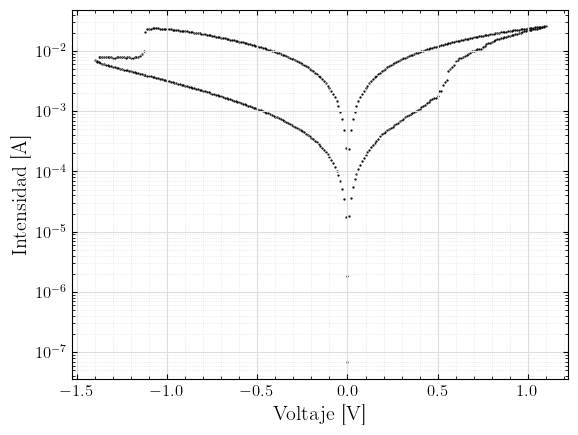

In [49]:
# Ruta proporcionada
ruta_exp_data = ruta_raiz + 'Datos_Experimentales/Ciclos_Experimentales'
ruta_archivo_set = ruta_exp_data + '/Cycle_p_1000.txt'
ruta_archivo_reset = ruta_exp_data + '/Cycle_n_1000.txt'

# Leer datos del archivo
data_set = np.loadtxt(ruta_archivo_set)
data_reset = np.loadtxt(ruta_archivo_reset)


fig, axes = plt.subplots()

pplt.config_ax(axes)

# Asumimos que los datos están en dos columnas: x e y
x_set = data_set[:, 0]
y_set = data_set[:, 1]

# Data reset
x_reset = data_reset[:, 0]
y_reset = abs(data_reset[:, 1])

axes.set_xlabel('Voltaje [V]')
axes.set_ylabel('Intensidad [A]')
axes.set_yscale('log')


axes.scatter(x_set, y_set, color='black', s=0.4, label='Set experimental')
axes.scatter(x_reset, y_reset, color='black', s=0.4, label='Segunda parte Set')

In [50]:
def leer_intensidades_en_intervalo(v_min, v_max):
    nombre_archivo = "Datos_Experimentales\Prim_Set.txt"

    # Cargar solo las dos primeras columnas con NumPy
    datos = np.loadtxt(nombre_archivo, usecols=(0, 1))  # Columna 0 = voltaje, Columna 1 = intensidad

    voltajes = datos[:, 0]  # Extraer columna de voltaje
    intensidades = datos[:, 1]  # Extraer columna de intensidad

    # Filtrar intensidades donde el voltaje esté en el intervalo [v_min, v_max]
    intensidades_filtradas = intensidades[(voltajes >= v_min) & (voltajes <= v_max)]
    voltajes_filtradas = voltajes[(voltajes >= v_min) & (voltajes <= v_max)]

    return voltajes_filtradas, intensidades_filtradas

In [ ]:
# Ejemplo de uso
v_min = 0.5
v_max = 0.6

voltajes, intensidades = leer_intensidades_en_intervalo(v_min, v_max) 
print(f"Intensidades en el intervalo [{v_min}, {v_max}]: {intensidades}")
print(f"Voltajes en el intervalo [{v_min}, {v_max}]: {voltajes}")

Intensidades en el intervalo [0.5, 0.6]: [0.0017615 0.0021295 0.002197  0.0026825 0.0030565 0.0033085 0.0046065
 0.0049895 0.005339  0.0058405 0.0067135]
Voltajes en el intervalo [0.5, 0.6]: [0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6 ]


In [52]:
def funcion_Ajuste(x, a, b):
  return a*x + b

print(intensidades)

# Assuming you want to fit the function to the intensities over the range of indices
x_data = np.arange(len(intensidades))
y_data = intensidades

parametros, errores = curve_fit(funcion_Ajuste, voltajes, intensidades)

errores = np.sqrt(np.diag(errores))

[0.0017615 0.0021295 0.002197  0.0026825 0.0030565 0.0033085 0.0046065
 0.0049895 0.005339  0.0058405 0.0067135]


In [53]:
print("El valor de la pendiente es: ", parametros[0], "y el valor del término independiente es: ", parametros[1])
print("El error de la pendiente es: ", errores[0], "y el error del término independiente es: ", errores[1])

El valor de la pendiente es:  0.05017636370020724 y el valor del término independiente es:  -0.02372204548965921
El error de la pendiente es:  0.0029961019753642682 y el error del término independiente es:  0.0016505775599389109


In [54]:
def plot_ajuste(x, y, xlabel="", ylabel=""):

    # Creación de la figura
    fig = plt.figure()

    # Gráfico de las medidas con barras de error
    plt.scatter(x, y, label="Medidas")

    # Gráfico de la recta de ajuste
    coeficientes = np.polyfit(x, y, 1)
    ajuste_lineal = np.poly1d(coeficientes)
    plt.plot(x, ajuste_lineal(x), "-", label="Ajuste lineal", linewidth=1.5, zorder=3)

    # Configuración de los ejes y la leyenda
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()

    plt.show()

    fig.savefig('AjusteLineal.pdf', format='pdf')

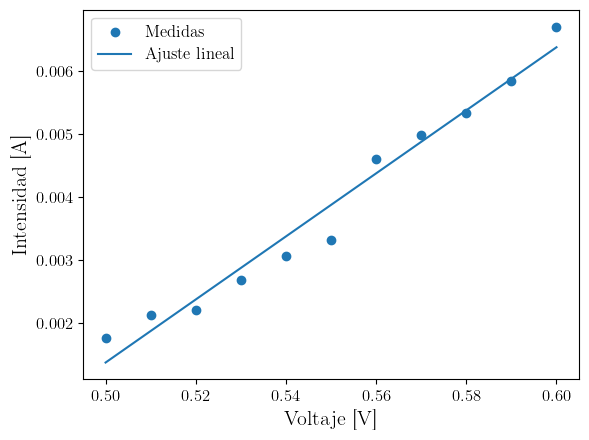

EL valor de la resistencia total es:  19.929702478537116 Ohmios


In [55]:
plot_ajuste(voltajes,intensidades, "Voltaje [V]", 'Intensidad [A]')
print("EL valor de la resistencia total es: ", 1/parametros[0], "Ohmios")

In [5]:
vector = np.linspace(0.5, 0.6, 100)

print(vector)

[0.5        0.5010101  0.5020202  0.5030303  0.5040404  0.50505051
 0.50606061 0.50707071 0.50808081 0.50909091 0.51010101 0.51111111
 0.51212121 0.51313131 0.51414141 0.51515152 0.51616162 0.51717172
 0.51818182 0.51919192 0.52020202 0.52121212 0.52222222 0.52323232
 0.52424242 0.52525253 0.52626263 0.52727273 0.52828283 0.52929293
 0.53030303 0.53131313 0.53232323 0.53333333 0.53434343 0.53535354
 0.53636364 0.53737374 0.53838384 0.53939394 0.54040404 0.54141414
 0.54242424 0.54343434 0.54444444 0.54545455 0.54646465 0.54747475
 0.54848485 0.54949495 0.55050505 0.55151515 0.55252525 0.55353535
 0.55454545 0.55555556 0.55656566 0.55757576 0.55858586 0.55959596
 0.56060606 0.56161616 0.56262626 0.56363636 0.56464646 0.56565657
 0.56666667 0.56767677 0.56868687 0.56969697 0.57070707 0.57171717
 0.57272727 0.57373737 0.57474747 0.57575758 0.57676768 0.57777778
 0.57878788 0.57979798 0.58080808 0.58181818 0.58282828 0.58383838
 0.58484848 0.58585859 0.58686869 0.58787879 0.58888889 0.5898